# DTLZ4 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1280
NGEN = 500
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz4_segura = partial(benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox = build_toolbox(func_dtlz4_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 1.0, 8.982635086898783e-05, 0.00019036283684440575, 0.5000002723815353, 0.49999977131564, 0.5000000089647268, 0.5000008030072426, 0.4999999901129451]
[1.0, 1.0, 1.0, 0.00019645360453446337, 0.49999988382434934, 0.49999961139951404, 0.5000000084579381, 0.5000008029506936, 0.49999999765257847]
[0.00016779896402010575, 0.003492262025118875, 0.9999188965524551, 0.9973031284035309, 0.009102349156429823, 0.03683035290679988, 0.7930747082905043, 0.6079095965472278, 0.5397788495662103]
[1.0, 1.0, 1.0, 1.0, 0.4999998890914969, 0.49999980072641836, 0.5000000092331709, 0.5000008029711935, 0.49999999760462877]
[0.8710795510006295, 6.0148862807026665e-05, 0.00011626557835249518, 0.9995713797254807, 0.011874074090382172, 0.9354906334552219, 0.6836825399770564, 0.19747511743597987, 0.2325456597977824]
[6.136383633075296e-06, 0.0004439347893572341, 0.00014803316440916824, 5.347909450761565e-05, 0.4999998822510297, 0.49999979854415244, 0.5000000082581657, 0.5000008030106788, 0.4999999970746554]
[

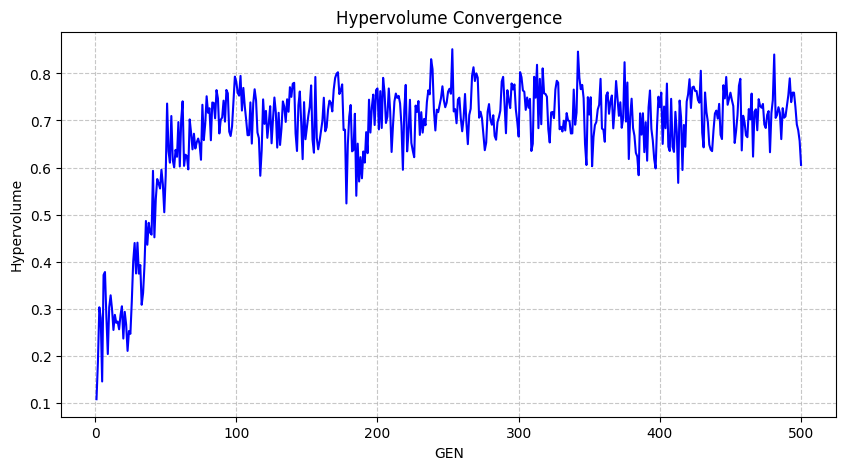

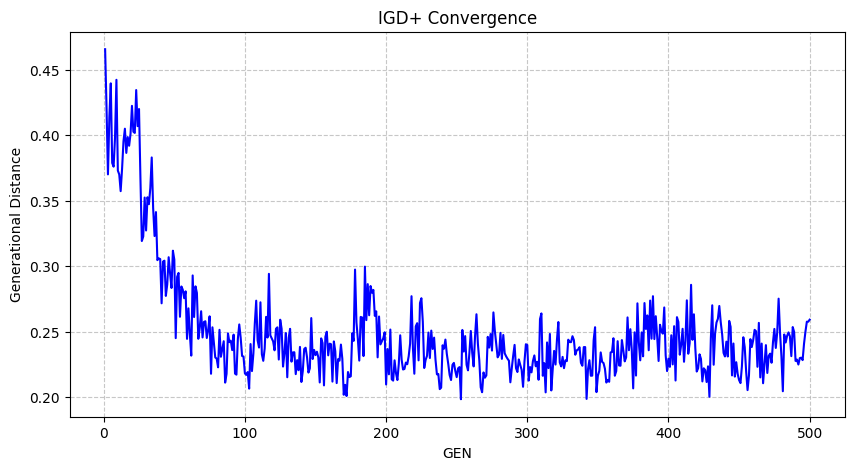

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()